In [8]:
from re import T
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [9]:
!pip install cupy-cuda12x

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from tqdm import tqdm
from skimage.measure import block_reduce
import random
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from skimage.measure import block_reduce

In [11]:
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    random.seed(seed)
    np.random.seed(seed)

In [12]:


def load_images_and_labels(directory, is_RGB = True, ext=".jpg", data_name=""):

    images, labels = [], []
    class_names = sorted(os.listdir(directory))

    for class_name in class_names:
        class_folder = os.path.join(directory, class_name)
        if not os.path.isdir(class_folder):
            continue

        for img_file in tqdm(os.listdir(class_folder), desc=f"Loading {class_name}"):
            if img_file.lower().endswith(ext):
                img_path = os.path.join(class_folder, img_file)
                try:
                  if is_RGB:
                    img = Image.open(img_path)
                  else:
                    img = Image.open(img_path).convert("L")

                  if data_name == "HAM10000":
                    img = img.transpose(Image.TRANSPOSE)
                    img = img.resize((150,200))
                    padding = (25, 0, 25, 0)  # (left, top, right, bottom)

                    img = ImageOps.expand(img, padding, fill=0)

                  img = np.array(img)
                  #plt.imshow(img)
                  #plt.show()
                  #print(f"Image shape: {img.shape}")
                  #img = img.astype(np.float32) / np.max(img)
                  #print(f"Image max: {img.max()}, min: {img.min()}")

                  images.append(img)
                  labels.append(class_name)

                except Exception as e:
                    print(f"Skipping {img_file}: {e}")

    return np.array(images), np.array(labels)

In [13]:
!pip install scikit-optimize

{'d1': 0.031036998663789027, 'd2': 0.036326616332991384, 'd3': 0.03933234754039598, 'z_after_mask4': 0.054475478675170795, 'z_after_lens': 0.032060780144914335}


Loading class_9: 100%|██████████| 40/40 [00:36<00:00,  1.11it/s]


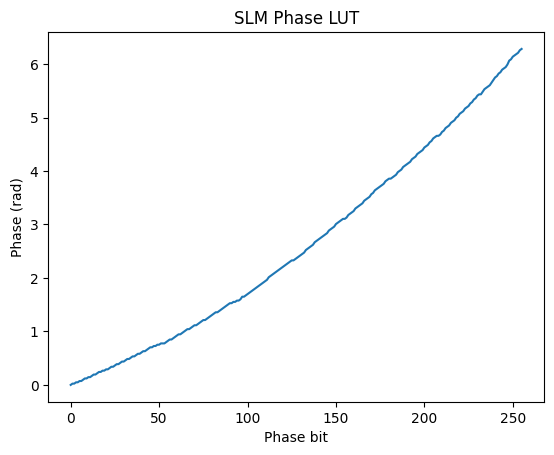

Loaded 680 images, 17 classes
Image shape: (200, 200, 3)


Seed 0: 39.71%


Seed 1: 45.59%


Seed 2: 42.65%


Seed 3: 37.50%


...

Seed 45: 42.65%


Seed 46: 43.38%


Seed 47: 44.12%


Seed 48: 43.38%


Seed 49: 45.59%
Mean accuracy: 41.51%
Std accuracy : 2.60%
Min accuracy : 35.29%
Max accuracy : 46.32%


In [ ]:

import cupy as cp
import numpy as np
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from tqdm import tqdm

""" used distance values: 
                {'d1': 0.031036998663789027,
               'd2': 0.036326616332991384,
               'd3': 0.03933234754039598,
               'z_after_mask4': 0.054475478675170795,
               'z_after_lens': 0.032060780144914335} """    

# =========================================================
# Load images
# =========================================================
path_image_folder = r"/content/drive/MyDrive/Nur_MPLC_Review/flowers17_parts_200x200/part1"
images, y_out = load_images_and_labels(path_image_folder, is_RGB=True)

# =========================================================
# Load LUT
# =========================================================
lut = np.loadtxt("/content/drive/MyDrive/Nur_MPLC_Review/nur_pluto.csv")
phi_max = 2.0 * np.pi
phase_lut = lut / lut.max() * phi_max

import matplotlib.pyplot as plt
plt.plot(phase_lut)
plt.xlabel("Phase bit")
plt.ylabel("Phase (rad)")
plt.title("SLM Phase LUT")
plt.show()

print(f"Loaded {len(images)} images, {len(np.unique(y_out))} classes")
print(f"Image shape: {images[0].shape}")

# FIX 1: LUT x-axis spans [0, 1] to match normalised inputs.
x_lut = np.linspace(0, 1, len(phase_lut))

def lut_function(input_values):
    index = np.digitize(input_values, x_lut) - 1
    index = np.clip(index, 0, len(phase_lut) - 1)
    return phase_lut[index]

# =========================================================
# Fixed parameters
# =========================================================
wavelength = 632e-9
k = 2 * np.pi / wavelength
dx = 2e-6

w0 = 50.0e-3
slit_width = 0.5e-2
slit_height = 2.0e-2

Nx = 2048
Ny = 4096

target_h = 45
target_w = 15

f_lens = 30e-3

cam_px = 6.9e-6
crop_w_px = round(150 * cam_px / dx)
crop_h_px = round(450 * cam_px / dx)

x_margin = (Nx - crop_w_px) // 2
y_margin = (Ny - crop_h_px) // 2

# =========================================================
# GPU grid
# =========================================================
x_arr = (cp.arange(Nx, dtype=cp.float32) - Nx // 2) * dx
y_arr = (cp.arange(Ny, dtype=cp.float32) - Ny // 2) * dx

X, Y = cp.meshgrid(x_arr, y_arr)

fx = cp.fft.fftfreq(Nx, d=dx).astype(cp.float32)
fy = cp.fft.fftfreq(Ny, d=dx).astype(cp.float32)

FX, FY = cp.meshgrid(fx, fy)

root_arg_real = (1.0 - (wavelength * FX)**2 - (wavelength * FY)**2).astype(cp.float32)

# =========================================================
# Cached propagation kernels
# =========================================================
H_cache = {}

def get_H(z):
    key = float(np.round(z, 8))
    if key not in H_cache:
        # FIX 2: -1j for evanescent decay.
        kz = cp.where(
            root_arg_real >= 0,
            cp.sqrt(cp.maximum(root_arg_real, 0.0)),
            -1j * cp.sqrt(cp.maximum(-root_arg_real, 0.0))
        ).astype(cp.complex64)
        H_cache[key] = cp.exp(1j * k * z * kz).astype(cp.complex64)
    return H_cache[key]

def propagate(E, z):
    return cp.fft.ifft2(cp.fft.fft2(E) * get_H(z))

# =========================================================
# Input field and lens
# =========================================================
E0 = cp.exp(-(X**2 + Y**2) / w0**2).astype(cp.complex64)

slit = (
    (cp.abs(X) <= slit_width / 2) &
    (cp.abs(Y) <= slit_height / 2)
).astype(cp.float32)

E_after_slit_prop = propagate(E0 * slit, 5.3e-2)

# E0 and slit no longer needed — free them immediately
del E0, slit
cp.get_default_memory_pool().free_all_blocks()

lens_phase = cp.exp(
    -1j * k * (X**2 + Y**2) / (2 * f_lens)
).astype(cp.complex64)

# X, Y, FX, FY, root_arg_real are still needed by get_H and lens_phase;
# free the coordinate grids once lens_phase is built.
del X, Y, FX, FY
cp.get_default_memory_pool().free_all_blocks()

# =========================================================
# Helpers
# =========================================================
UPSCALE = 4
ones4  = np.ones((UPSCALE, UPSCALE), dtype=np.float32)
# FIX 3: 50×50 masks need 16×16 kron to reach 800×800.
ones16 = np.ones((UPSCALE * UPSCALE, UPSCALE * UPSCALE), dtype=np.float32)

def build_image_composite(img):
    comp = np.zeros((640 * UPSCALE, 200 * UPSCALE), dtype=np.float32)
    comp[0          : 200*UPSCALE, :] = np.kron(img[:, :, 0], ones4)
    comp[220*UPSCALE: 420*UPSCALE, :] = np.kron(img[:, :, 1], ones4)
    comp[440*UPSCALE: 640*UPSCALE, :] = np.kron(img[:, :, 2], ones4)
    return comp

def build_random(maskA, maskB, maskC):
    comp = np.zeros((640 * UPSCALE, 200 * UPSCALE), dtype=np.float32)
    comp[0          : 200*UPSCALE, :] = np.kron(maskA, ones16)
    comp[220*UPSCALE: 420*UPSCALE, :] = np.kron(maskB, ones16)
    comp[440*UPSCALE: 640*UPSCALE, :] = np.kron(maskC, ones16)
    return comp

def place(comp):
    phase = np.zeros((Ny, Nx), dtype=np.float32)
    h, w = comp.shape
    y0 = Ny // 2 - h // 2
    x0 = Nx // 2 - w // 2
    phase[y0:y0+h, x0:x0+w] = lut_function(comp)
    return cp.asarray(phase, dtype=cp.float32)

def gpu_downsample(I_crop):
    I_crop = I_crop / (I_crop.max() + 1e-12)
    h, w = I_crop.shape
    new_h = target_h * 6
    new_w = target_w * 6
    y0 = h // 2 - new_h // 2
    x0 = w // 2 - new_w // 2
    I_small = I_crop[y0:y0+new_h, x0:x0+new_w]
    I_pool = I_small.reshape(target_h, 6, target_w, 6).mean(axis=(1, 3))
    I_pool = I_pool / (I_pool.max() + 1e-12)
    return cp.asnumpy(I_pool).astype(np.float32)

# =========================================================
# Optical processing
# =========================================================
def process_image(img_norm, phase2, phase3, phase4, d1, d2, d3, z_after_mask4, z_after_lens):
    phase1 = place(build_image_composite(img_norm.astype(np.float32)))

    E1 = E_after_slit_prop * cp.exp(1j * phase1).astype(cp.complex64)
    del phase1

    E2 = propagate(E1, d1);  del E1
    E3 = E2 * cp.exp(1j * phase2).astype(cp.complex64);  del E2

    E4 = propagate(E3, d2);  del E3
    E5 = E4 * cp.exp(1j * phase3).astype(cp.complex64);  del E4

    E6 = propagate(E5, d3);  del E5
    E7 = E6 * cp.exp(1j * phase4).astype(cp.complex64);  del E6

    E8     = propagate(E7, z_after_mask4);  del E7
    E_lens = E8 * lens_phase;               del E8
    E_last = propagate(E_lens, z_after_lens); del E_lens

    E_crop = E_last[y_margin:-y_margin, x_margin:-x_margin]; del E_last
    I_crop = cp.abs(E_crop) ** 2;           del E_crop

    result = gpu_downsample(I_crop);        del I_crop
    return result

# =========================================================
# Random phase masks
# =========================================================
def make_random_phases(seed):
    rng = np.random.default_rng(seed)
    MASKS = rng.integers(0, 256, size=(9, 50, 50)).astype(np.float32) / 255.0
    # NO kron here — build_random handles upscaling with ones16.
    phase2 = place(build_random(*MASKS[0:3]))
    phase3 = place(build_random(*MASKS[3:6]))
    phase4 = place(build_random(*MASKS[6:9]))
    return phase2, phase3, phase4

# =========================================================
# Trial runners
# =========================================================
def run_trial(seed, d1, d2, d3, z_after_mask4, z_after_lens):
    phase2, phase3, phase4 = make_random_phases(seed)

    X_out = np.zeros((len(images), target_h, target_w), dtype=np.float32)

    for i, img in enumerate(tqdm(images, desc=f"Full trial seed={seed}", leave=False)):
        X_out[i] = process_image(
            img / 255.0,
            phase2, phase3, phase4,
            d1, d2, d3,
            z_after_mask4, z_after_lens
        )

    # Free phase masks and flush pool after the trial
    del phase2, phase3, phase4
    cp.get_default_memory_pool().free_all_blocks()

    return X_out

# =========================================================
# Classification
# =========================================================
def classify(X_out):
    X_flat = X_out.reshape(X_out.shape[0], -1)
    X_train, X_test, y_train, y_test = train_test_split(
        X_flat, y_out,
        test_size=0.2, random_state=42, stratify=y_out
    )
    le = LabelEncoder()
    y_tr = le.fit_transform(y_train)
    y_te = le.transform(y_test)
    clf = RidgeClassifier(alpha=1)
    clf.fit(X_train, y_tr)
    return accuracy_score(y_te, clf.predict(X_test))



params = {'d1': 0.031036998663789027,
               'd2': 0.036326616332991384,
               'd3': 0.03933234754039598,
               'z_after_mask4': 0.054475478675170795,
               'z_after_lens': 0.032060780144914335}



N_SEEDS = 50
acc_s = []
for i in range(N_SEEDS):
    X_out = run_trial(seed=i, **params)
    acc_s.append(classify(X_out))
    print(f"Seed {i}: {acc_s[-1]*100:.2f}%")

print(f"Mean accuracy: {np.mean(acc_s)*100:.2f}%")
print(f"Std accuracy : {np.std(acc_s)*100:.2f}%")
print(f"Min accuracy : {np.min(acc_s)*100:.2f}%")
print(f"Max accuracy : {np.max(acc_s)*100:.2f}%")

#SOC

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict, Optional, Callable
import time
import random

# ============================================================================
# SOC SANDPILE CORE
# ============================================================================

def relax_sandpile_2d(heights: np.ndarray,
                     threshold: int = 4,
                     grains_per_neighbor: int = 1) -> Tuple[np.ndarray, int]:
    """Relax 2D sandpile, return avalanche map and size."""
    H, W = heights.shape
    avalanche_map = np.zeros_like(heights, dtype=int)
    grains_lost = 4 * grains_per_neighbor

    while True:
        unstable = heights >= threshold
        if not np.any(unstable):
            break

        toppled = unstable.astype(int)
        avalanche_map += toppled
        heights -= toppled * grains_lost

        heights[:-1, :] += toppled[1:, :] * grains_per_neighbor
        heights[1:, :] += toppled[:-1, :] * grains_per_neighbor
        heights[:, :-1] += toppled[:, 1:] * grains_per_neighbor
        heights[:, 1:] += toppled[:, :-1] * grains_per_neighbor

    return avalanche_map, int(avalanche_map.sum())


# ============================================================================
# INITIALIZATION
# ============================================================================

def initialize_sandpile_grids(mask_size: Tuple[int, int]) -> np.ndarray:
    H, W = mask_size
    return np.zeros((H, W), dtype=int)

# ============================================================================
# THERMALIZATION
# ============================================================================

def thermalize_sandpiles(sandpile_grid: np.ndarray,
                        threshold: int = 4,
                        grains_per_neighbor: int = 1,
                        n_drops: int = 50000):
    """Drive sandpiles to critical state."""

    print("Thermalizing sandpiles to critical state...")
    for _ in range(n_drops):
        y = np.random.randint(0, sandpile_grid.shape[0])
        x = np.random.randint(0, sandpile_grid.shape[1])
        sandpile_grid[y, x] += 1
        relax_sandpile_2d(sandpile_grid, threshold, grains_per_neighbor)

    print(f"Mean height = {np.mean(sandpile_grid):.2f}")


# ============================================================================
# AVALANCHE GENERATION
# ============================================================================

def generate_avalanche_pattern(sandpile_grid: np.ndarray,
                              threshold: int = 4,
                              grains_per_neighbor: int = 1) -> Tuple[np.ndarray, int]:
    """Trigger single avalanche, return avalanche map."""

    H, W = sandpile_grid.shape
    y = np.random.randint(0, H)
    x = np.random.randint(0, W)
    sandpile_grid[y, x] += 1

    return relax_sandpile_2d(sandpile_grid, threshold, grains_per_neighbor)


# ============================================================================
# PERTURBATION AND MASK UPDATE (UINT8)
# ============================================================================

def perturb_mask_uint8(mask: np.ndarray,
                      avalanche_map: np.ndarray,
                      perturbation_scale: int,
                      avalanche_size: int) -> np.ndarray:

    trial_mask = (mask.copy()).astype(np.float32)  # Use int16 for intermediate calculations

    # Adaptive scale based on avalanche size
    #adaptive_scale = perturbation_scale * np.log10(max(2, avalanche_size))
    adaptive_scale = perturbation_scale
    # Perturbation at avalanche sites only
    mean = 0
    std = adaptive_scale
    perturbation = np.random.normal(mean, std, mask.shape)
    perturbation *= (avalanche_map > 0)

    # Apply perturbation
    trial_mask = trial_mask + perturbation.astype(np.int16)

    # Wrap to [0, 255]
    trial_mask = trial_mask % 256
    trial_mask = np.clip(trial_mask, 0, 255)

    return trial_mask.astype(np.uint8)

# ============================================================================
# MAIN OPTIMIZATION LOOP
# ============================================================================

def soc_optimize_experimental(
    measure_accuracy_fn: Callable,
    upload_masks_fn: Callable,
    initial_mask: np.ndarray,
    mask_size: Tuple[int, int] = (50, 50),
    max_iterations: int = 2000,
    threshold: int = 4,
    grains_per_neighbor: int = 1,
    perturbation_scale: int = 50,
    verbose: bool = True,
    save_every: int = 50,
    random_seed: int = 42) -> Dict:

    print(f"Setting random seed to {random_seed} for reproducibility...")
    np.random.seed(random_seed)
    random.seed(random_seed)  # Also seed Python's random module

    # ========================================================================
    # INITIALIZATION
    # ========================================================================

    best_mask = initial_mask.copy()
    sandpile_grid = initialize_sandpile_grids(mask_size)

    accuracy_history = []
    avalanche_size_history = []
    mask_history = []
    best_accuracy = -np.inf

    # ========================================================================
    # THERMALIZATION
    # ========================================================================

    thermalize_sandpiles(sandpile_grid, threshold, grains_per_neighbor,
                        n_drops=150*150*3)
    out_imgs = upload_masks_fn(best_mask
    )

    best_accuracy = measure_accuracy_fn(out_imgs)

    accuracy_history.append(best_accuracy)
    mask_history.append(best_mask)

    if verbose:
        print(f"\nInitial accuracy: {best_accuracy:.4f} ")
        print(f"--- Starting SOC optimization ({max_iterations} iterations) ---\n")

    start_time = time.time()

    # ========================================================================
    # MAIN LOOP
    # ========================================================================

    for iteration in range(max_iterations):
        while True:
            avalanche_map, avalanche_size = generate_avalanche_pattern(
                sandpile_grid, threshold, grains_per_neighbor
            )
            if avalanche_size < 1:
                continue
            else:
                break

        trial_mask = perturb_mask_uint8(
            best_mask.copy(), avalanche_map,
            perturbation_scale, avalanche_size
            )

        out_1 = upload_masks_fn(trial_mask)

        # Measure accuracy
        print(f"iteration {iteration}: Q1r \n Avalanche size : {avalanche_size}")
        trial_accuracy = measure_accuracy_fn(out_1)


        # Accept/reject
        if trial_accuracy > (best_accuracy - 0.001):
            best_accuracy = trial_accuracy
            best_mask = trial_mask.copy()
            accuracy_history.append(best_accuracy)
            if verbose:
                print(f"*** New best: {best_accuracy:.4f} at iteration {iteration+1}")

        else:
            accuracy_history.append(trial_accuracy)

    return accuracy_history


Loading class_9: 100%|██████████| 40/40 [00:00<00:00, 435.78it/s]


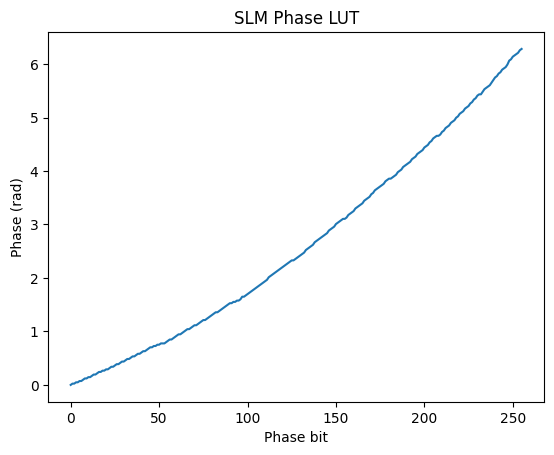

Loaded 680 images, 17 classes
Image shape: (200, 200, 3)
Setting random seed to 8 for reproducibility...
Thermalizing sandpiles to critical state...
Mean height = 2.10

Initial accuracy: 0.3603 
--- Starting SOC optimization (100 iterations) ---

iteration 0: Q1r 
 Avalanche size : 207
iteration 1: Q1r 
 Avalanche size : 340
iteration 2: Q1r 
 Avalanche size : 505
*** New best: 0.3897 at iteration 3
iteration 3: Q1r 
 Avalanche size : 17
*** New best: 0.3971 at iteration 4
iteration 4: Q1r 
 Avalanche size : 59
iteration 5: Q1r 
 Avalanche size : 2
*** New best: 0.4044 at iteration 6
iteration 6: Q1r 
 Avalanche size : 1
iteration 7: Q1r 
 Avalanche size : 1
*** New best: 0.4044 at iteration 8
iteration 8: Q1r 
 Avalanche size : 25
iteration 9: Q1r 
 Avalanche size : 14
iteration 10: Q1r 
 Avalanche size : 1482
iteration 11: Q1r 
 Avalanche size : 41
*** New best: 0.4191 at iteration 12
iteration 12: Q1r 
 Avalanche size : 17
iteration 13: Q1r 
 Avalanche size : 47
*** New best: 0.4265

In [ ]:
import cupy as cp
import numpy as np
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
from tqdm import tqdm

# =========================================================
path_image_folder = r"/content/drive/MyDrive/Nur_MPLC_Review/flowers17_parts_200x200/part2"
images, y_out = load_images_and_labels(path_image_folder, is_RGB=True)
# =========================================================
# Load LUT
# =========================================================
lut = np.loadtxt("/content/drive/MyDrive/Nur_MPLC_Review/nur_pluto.csv")
phi_max = 2.0 * np.pi
phase_lut = lut / lut.max() * phi_max

import matplotlib.pyplot as plt
plt.plot(phase_lut)
plt.xlabel("Phase bit")
plt.ylabel("Phase (rad)")
plt.title("SLM Phase LUT")
plt.show()

print(f"Loaded {len(images)} images, {len(np.unique(y_out))} classes")
print(f"Image shape: {images[0].shape}")

# FIX 1: LUT x-axis spans [0, 1] to match normalised inputs.
x_lut = np.linspace(0, 1, len(phase_lut))

def lut_function(input_values):
    index = np.digitize(input_values, x_lut) - 1
    index = np.clip(index, 0, len(phase_lut) - 1)
    return phase_lut[index]

# =========================================================
# Fixed parameters
# =========================================================
wavelength = 632e-9
k = 2 * np.pi / wavelength
dx = 2e-6

w0 = 50.0e-3
slit_width = 0.5e-2
slit_height = 2.0e-2

Nx = 2048
Ny = 4096

target_h = 45
target_w = 15

f_lens = 30e-3

cam_px = 6.9e-6
crop_w_px = round(150 * cam_px / dx)
crop_h_px = round(450 * cam_px / dx)

x_margin = (Nx - crop_w_px) // 2
y_margin = (Ny - crop_h_px) // 2

# =========================================================
# GPU grid
# =========================================================
x_arr = (cp.arange(Nx, dtype=cp.float32) - Nx // 2) * dx
y_arr = (cp.arange(Ny, dtype=cp.float32) - Ny // 2) * dx

X, Y = cp.meshgrid(x_arr, y_arr)

fx = cp.fft.fftfreq(Nx, d=dx).astype(cp.float32)
fy = cp.fft.fftfreq(Ny, d=dx).astype(cp.float32)

FX, FY = cp.meshgrid(fx, fy)

root_arg_real = (1.0 - (wavelength * FX)**2 - (wavelength * FY)**2).astype(cp.float32)

# =========================================================
# Cached propagation kernels
# =========================================================
H_cache = {}

def get_H(z):
    key = float(np.round(z, 8))
    if key not in H_cache:
        # FIX 2: -1j for evanescent decay.
        kz = cp.where(
            root_arg_real >= 0,
            cp.sqrt(cp.maximum(root_arg_real, 0.0)),
            -1j * cp.sqrt(cp.maximum(-root_arg_real, 0.0))
        ).astype(cp.complex64)
        H_cache[key] = cp.exp(1j * k * z * kz).astype(cp.complex64)
    return H_cache[key]

def propagate(E, z):
    return cp.fft.ifft2(cp.fft.fft2(E) * get_H(z))

# =========================================================
# Input field and lens
# =========================================================
E0 = cp.exp(-(X**2 + Y**2) / w0**2).astype(cp.complex64)

slit = (
    (cp.abs(X) <= slit_width / 2) &
    (cp.abs(Y) <= slit_height / 2)
).astype(cp.float32)

E_after_slit_prop = propagate(E0 * slit, 5.3e-2)

# E0 and slit no longer needed — free them immediately
del E0, slit
cp.get_default_memory_pool().free_all_blocks()

lens_phase = cp.exp(
    -1j * k * (X**2 + Y**2) / (2 * f_lens)
).astype(cp.complex64)

# X, Y, FX, FY, root_arg_real are still needed by get_H and lens_phase;
# free the coordinate grids once lens_phase is built.
del X, Y, FX, FY
cp.get_default_memory_pool().free_all_blocks()

# =========================================================
# Helpers
# =========================================================
UPSCALE = 4
ones4  = np.ones((UPSCALE, UPSCALE), dtype=np.float32)
# FIX 3: 50×50 masks need 16×16 kron to reach 800×800.
ones16 = np.ones((UPSCALE * UPSCALE, UPSCALE * UPSCALE), dtype=np.float32)

def build_image_composite(img):
    comp = np.zeros((640 * UPSCALE, 200 * UPSCALE), dtype=np.float32)
    comp[0          : 200*UPSCALE, :] = np.kron(img[:, :, 0], ones4)
    comp[220*UPSCALE: 420*UPSCALE, :] = np.kron(img[:, :, 1], ones4)
    comp[440*UPSCALE: 640*UPSCALE, :] = np.kron(img[:, :, 2], ones4)
    return comp

def build_random(maskA, maskB, maskC):
    comp = np.zeros((640 * UPSCALE, 200 * UPSCALE), dtype=np.float32)
    comp[0          : 200*UPSCALE, :] = np.kron(maskA, ones16)
    comp[220*UPSCALE: 420*UPSCALE, :] = np.kron(maskB, ones16)
    comp[440*UPSCALE: 640*UPSCALE, :] = np.kron(maskC, ones16)
    return comp

def place(comp):
    phase = np.zeros((Ny, Nx), dtype=np.float32)
    h, w = comp.shape
    y0 = Ny // 2 - h // 2
    x0 = Nx // 2 - w // 2
    phase[y0:y0+h, x0:x0+w] = lut_function(comp)
    return cp.asarray(phase, dtype=cp.float32)

def gpu_downsample(I_crop):
    I_crop = I_crop / (I_crop.max() + 1e-12)
    h, w = I_crop.shape
    new_h = target_h * 6
    new_w = target_w * 6
    y0 = h // 2 - new_h // 2
    x0 = w // 2 - new_w // 2
    I_small = I_crop[y0:y0+new_h, x0:x0+new_w]
    I_pool = I_small.reshape(target_h, 6, target_w, 6).mean(axis=(1, 3))
    I_pool = I_pool / (I_pool.max() + 1e-12)
    return cp.asnumpy(I_pool).astype(np.float32)

# =========================================================
# Optical processing
# =========================================================
def process_image(img_norm, phase2, phase3, phase4, d1, d2, d3, z_after_mask4, z_after_lens):
    phase1 = place(build_image_composite(img_norm.astype(np.float32)))

    E1 = E_after_slit_prop * cp.exp(1j * phase1).astype(cp.complex64)
    del phase1

    E2 = propagate(E1, d1);  del E1
    E3 = E2 * cp.exp(1j * phase2).astype(cp.complex64);  del E2

    E4 = propagate(E3, d2);  del E3
    E5 = E4 * cp.exp(1j * phase3).astype(cp.complex64);  del E4

    E6 = propagate(E5, d3);  del E5
    E7 = E6 * cp.exp(1j * phase4).astype(cp.complex64);  del E6

    E8     = propagate(E7, z_after_mask4);  del E7
    E_lens = E8 * lens_phase;               del E8
    E_last = propagate(E_lens, z_after_lens); del E_lens

    E_crop = E_last[y_margin:-y_margin, x_margin:-x_margin]; del E_last
    I_crop = cp.abs(E_crop) ** 2;           del E_crop

    result = gpu_downsample(I_crop);        del I_crop
    return result

# =========================================================
# Random phase masks
# =========================================================
def make_random_phases(MASKS):
    MASKS = MASKS/255.0
    phase2 = place(build_random(*MASKS[0:3]))
    phase3 = place(build_random(*MASKS[3:6]))
    phase4 = place(build_random(*MASKS[6:9]))
    return phase2, phase3, phase4

# =========================================================
# Trial runners
# =========================================================
def run_trial(trial_mask):
    phase2, phase3, phase4 = make_random_phases(trial_mask)
    d1,d2,d3 = best_params['d1'],best_params['d2'],best_params['d3']
    z_after_mask4 = best_params['z_after_mask4']
    z_after_lens = best_params['z_after_lens']
    X_out = np.zeros((len(images), target_h, target_w), dtype=np.float32)

    for i, img in enumerate(images):
        X_out[i] = process_image(
            img / 255.0,
            phase2, phase3, phase4,
            d1, d2, d3,
            z_after_mask4, z_after_lens
        )

    # Free phase masks and flush pool after the trial
    del phase2, phase3, phase4
    cp.get_default_memory_pool().free_all_blocks()

    return X_out

# =========================================================
# Classification
# =========================================================
def classify(X_out):
    X_flat = X_out.reshape(X_out.shape[0], -1)
    X_train, X_test, y_train, y_test = train_test_split(
        X_flat, y_out,
        test_size=0.2, random_state=42, stratify=y_out
    )
    le = LabelEncoder()
    y_tr = le.fit_transform(y_train)
    y_te = le.transform(y_test)
    clf = RidgeClassifier(alpha=1)
    clf.fit(X_train, y_tr)
    return accuracy_score(y_te, clf.predict(X_test))



best_params = {'d1': 0.031036998663789027,
               'd2': 0.036326616332991384,
               'd3': 0.03933234754039598,
               'z_after_mask4': 0.054475478675170795,
               'z_after_lens': 0.032060780144914335}

rng = np.random.default_rng(42)
initial_mask = rng.integers(0, 256, size=(9, 50, 50)).astype(np.float32)

for i in range(1,20):
    c = soc_optimize_experimental(
                              classify,
                              run_trial,
                              initial_mask,
                              mask_size=(50, 50),
                              max_iterations=100,
                              threshold=4,
                              grains_per_neighbor=1,
                              perturbation_scale=50,
                              random_seed=i)

    np.save(f"/content/drive/MyDrive/Nur_MPLC_Review/acc_history_seed{i}.npy",c)